In [1]:
# import os
# from glob import glob
# import numpy as np
# import nibabel as nib
# import PIL.Image as Image

# path=r"/mnt/bb586fde-943d-4653-af27-224147bfba7e/Medgemma/sam/sam3/test"

# files = glob(os.path.join(path, "BraTS*100","BraTS*t2f.nii.gz"))
# files.sort()
# for file in files:
#     if "t2f.nii.gz" in file:
#         img = nib.load(file)
#         data = img.get_fdata()
#         for i in range(data.shape[2]):
#             save_path = path + "/png/"
#             slice = data[:,:,i]
#             if np.sum(slice)!=0:
#                 #Save slice as png as well as jpg
#                 png_slice = (slice - np.min(slice)) / (np.max(slice) - np.min(slice)) * 255
#                 png_slice = png_slice.astype(np.uint8)

#                 jpg_slice = (slice - np.min(slice)) / (np.max(slice) - np.min(slice))
#                 jpg_slice = (jpg_slice * 255).astype(np.uint8)

#                 im = Image.fromarray(slice)
#                 save_path = save_path + file.split("/")[-1].replace(".nii.gz","")
#                 print(save_path + "_slice_" + str(i) + ".png")
#                 os.makedirs(os.path.dirname(save_path), exist_ok=True)
#                 im.save(save_path + "_slice_" + str(i) + ".png")

In [2]:
#Get bounding box of non zero region in 3D numpy array
import numpy as np
import nibabel as nib
import PIL.Image as Image
from glob import glob
import os

seg_path = r"/mnt/bb586fde-943d-4653-af27-224147bfba7e/Medgemma/sam/sam3/test/BraTS-GLI-00005-100/BraTS-GLI-00005-100-seg.nii.gz"
path=r"/mnt/bb586fde-943d-4653-af27-224147bfba7e/Medgemma/sam/sam3/test"
slice_id = 133

seg_img = nib.load(seg_path)
seg_data = seg_img.get_fdata()
seg_slice = seg_data[:,:,slice_id]
non_zero_coords = np.argwhere(seg_slice > 0)
if non_zero_coords.size > 0:
    y_min, x_min = non_zero_coords.min(axis=0)
    y_max, x_max = non_zero_coords.max(axis=0)
    print(f"Bounding box - x: ({x_min}, {x_max}), y: ({y_min}, {y_max})")
else:
    print("No non-zero region found in the slice.")

seg_slice_png = (seg_slice - np.min(seg_slice)) / (np.max(seg_slice) - np.min(seg_slice)) * 255
seg_slice_png = seg_slice_png.astype(np.uint8)
im = Image.fromarray(seg_slice_png)
im.save(path + "/png/BraTS-GLI-00005-100-seg_slice_" + str(slice_id) + ".png")

Bounding box - x: (42, 84), y: (94, 127)


# Only 

In [3]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch

import sam3
from PIL import Image
from sam3 import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results, show_points, show_mask


In [4]:

# Load the model
model = build_sam3_image_model(enable_inst_interactivity=True)
processor = Sam3Processor(model, resolution=1008, device="cuda:0")
# Load an image
image_path = "/mnt/bb586fde-943d-4653-af27-224147bfba7e/Medgemma/sam/sam3/test/png/BraTS-GLI-00005-100-t2f_slice_133.png"
image = Image.open(image_path)
#Print the size of the image
print("Image size:", image.size)
width, height = image.size
image = image.convert("RGB")
# image = image.resize((1008, 1008))

print("Resized image size:", image.size)
inference_state = processor.set_image(image)


Image size: (218, 182)
Resized image size: (218, 182)


# Bounding Box

Normalized box input: [0.2637614607810974, 0.5906593203544617, 0.16055046021938324, 0.19230769574642181]
found 1 object(s)
Normalized box input: [0.25229358673095703, 0.5769230723381042, 0.3211009204387665, 0.38461539149284363]
found 1 object(s)


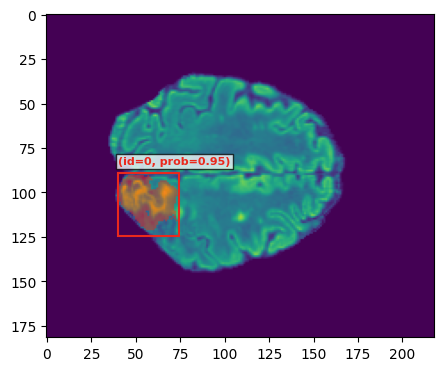

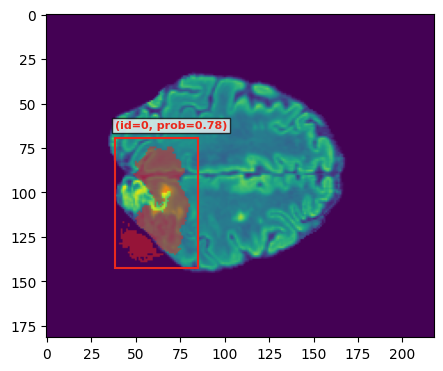

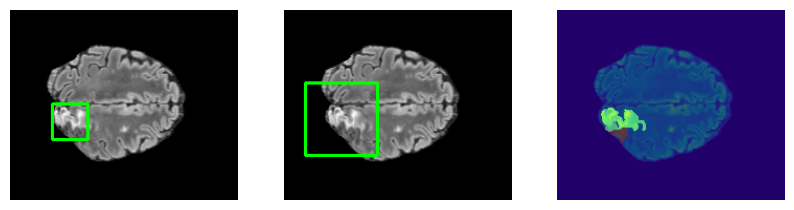

In [5]:
box_input_xywh = torch.tensor([40.0, 90.0, 35.0, 35.0]).view(-1, 4)
box_input_cxcywh = box_xywh_to_cxcywh(box_input_xywh)

norm_box_cxcywh = normalize_bbox(box_input_cxcywh, width, height).flatten().tolist()
print("Normalized box input:", norm_box_cxcywh)

processor.reset_all_prompts(inference_state)
inference_state_1 = processor.add_geometric_prompt(
    state=inference_state, box=norm_box_cxcywh, label=True
)

img0 = Image.open(image_path)
image_with_box = draw_box_on_image(img0, box_input_xywh.flatten().tolist())
plot_results(img0, inference_state_1)


#################################BBOX PLOTTING DONE##########################################
box_input_xywh_2 = torch.tensor([20.0, 70.0, 70.0, 70.0]).view(-1, 4)
box_input_cxcywh_2 = box_xywh_to_cxcywh(box_input_xywh_2)

norm_box_cxcywh_2 = normalize_bbox(box_input_cxcywh_2, width, height).flatten().tolist()
print("Normalized box input:", norm_box_cxcywh_2)

processor.reset_all_prompts(inference_state_1)
inference_state_2 = processor.add_geometric_prompt(
    state=inference_state_1, box=norm_box_cxcywh_2, label=True
)

image_with_box_2 = draw_box_on_image(img0, box_input_xywh_2.flatten().tolist())

plot_results(img0, inference_state_2)
################################################################################

seg_slice_path = r"/mnt/bb586fde-943d-4653-af27-224147bfba7e/Medgemma/sam/sam3/test/png/BraTS-GLI-00005-100-seg_slice_133.png"
seg_image = Image.open(seg_slice_path)

plt.figure(figsize=(10, 15))
plt.subplot(1, 3, 1)
plt.imshow(image_with_box)
plt.axis("off")  # Hide the axis
plt.subplot(1, 3, 2)
plt.imshow(image_with_box_2)
plt.axis("off")  # Hide the axis
plt.subplot(1, 3, 3)
plt.imshow(img0)
plt.imshow(seg_image, alpha=0.5, cmap='jet')  # Adjust alpha for transparency
plt.axis("off")  # Hide the axis
plt.show()


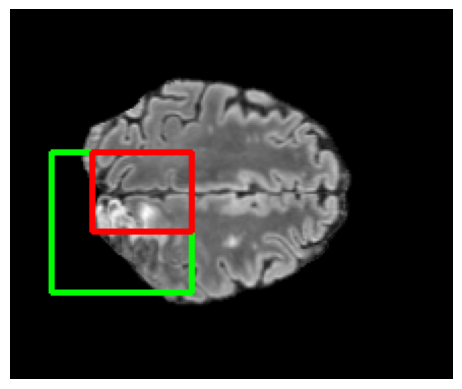

found 1 object(s)


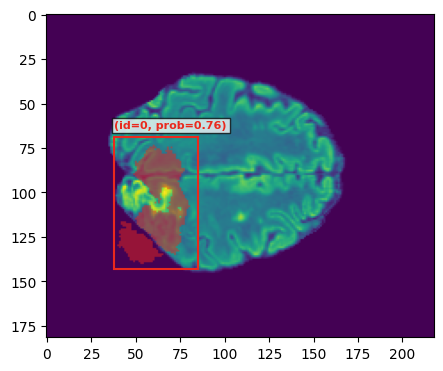

In [6]:
box_input_xywh = [[20.0, 70.0, 70.0, 70.0], [40, 70, 50.0, 40.0]]
box_input_cxcywh = box_xywh_to_cxcywh(torch.tensor(box_input_xywh).view(-1,4))
norm_boxes_cxcywh = normalize_bbox(box_input_cxcywh, width, height).tolist()

box_labels = [True, False]

processor.reset_all_prompts(inference_state_2)

for box, label in zip(norm_boxes_cxcywh, box_labels):
    inference_state_3 = processor.add_geometric_prompt(
        state=inference_state_2, box=box, label=label
    )

img0 = Image.open(image_path)
image_with_box_2 = img0
for i in range(len(box_input_xywh)):
    if box_labels[i] == 1:
        color = (0, 255, 0)
    else:
        color = (255, 0, 0)
    image_with_box_2 = draw_box_on_image(image_with_box_2, box_input_xywh[i], color)
plt.imshow(image_with_box_2)
plt.axis("off")  # Hide the axis
plt.show()

plot_results(img0, inference_state_3)

# Point Prompt

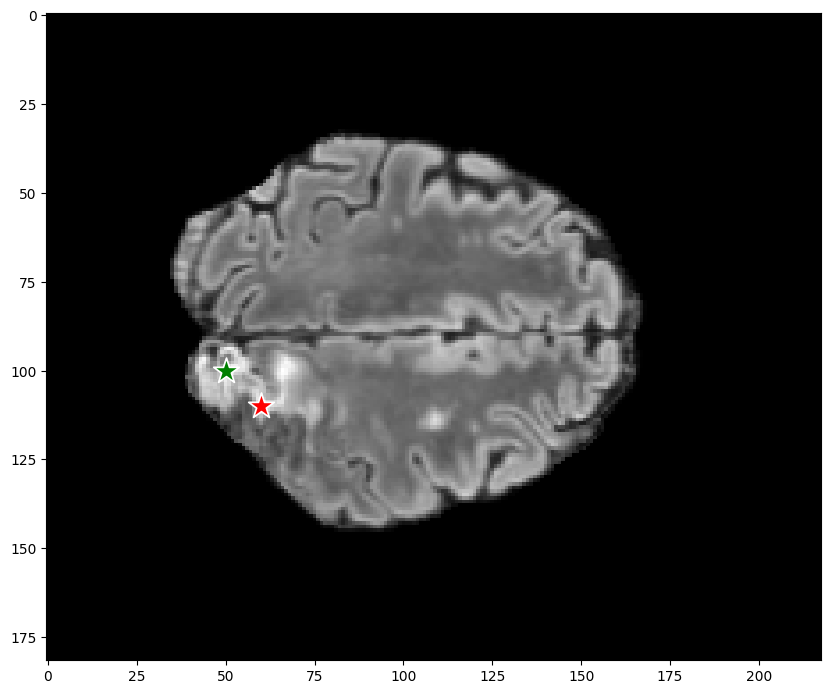

In [7]:
input_point = np.array([[50, 100], [60, 110]])
input_label = np.array([1, 0])

plt.figure(figsize=(10, 10))
plt.imshow(image)
show_points(input_point, input_label, plt.gca())
plt.axis('on')
plt.show()  

In [29]:
masks, scores, logits = model.predict_inst(
    inference_state,
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)
sorted_ind = np.argsort(scores)[::-1]
masks = masks[sorted_ind]
scores = scores[sorted_ind]
logits = logits[sorted_ind]

In [30]:
def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2) 
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))    

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        show_mask(mask, plt.gca(), borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())
        if box_coords is not None:
            # boxes
            show_box(box_coords, plt.gca())
        if len(scores) > 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        # plt.axis('off')
        plt.show()

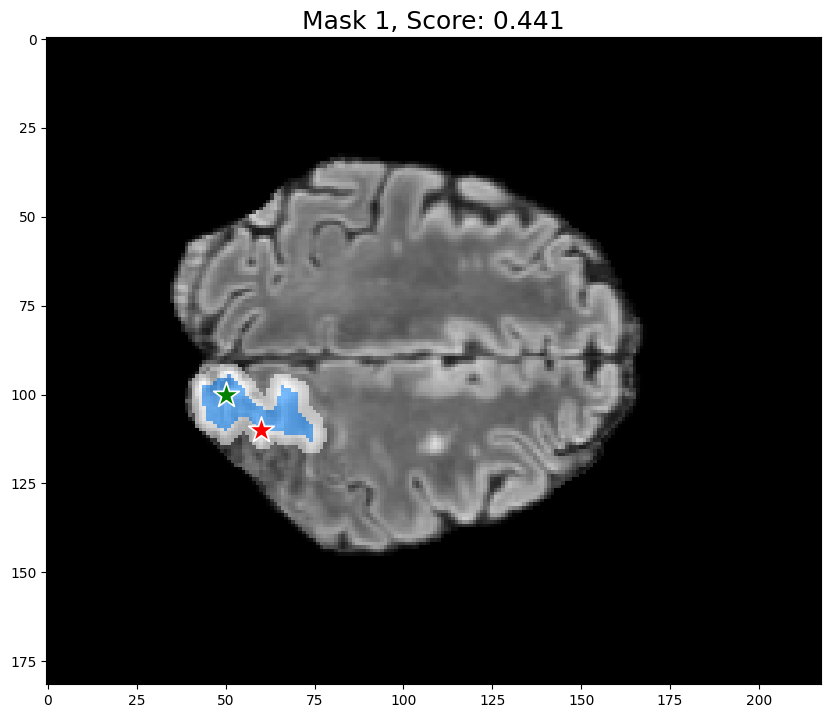

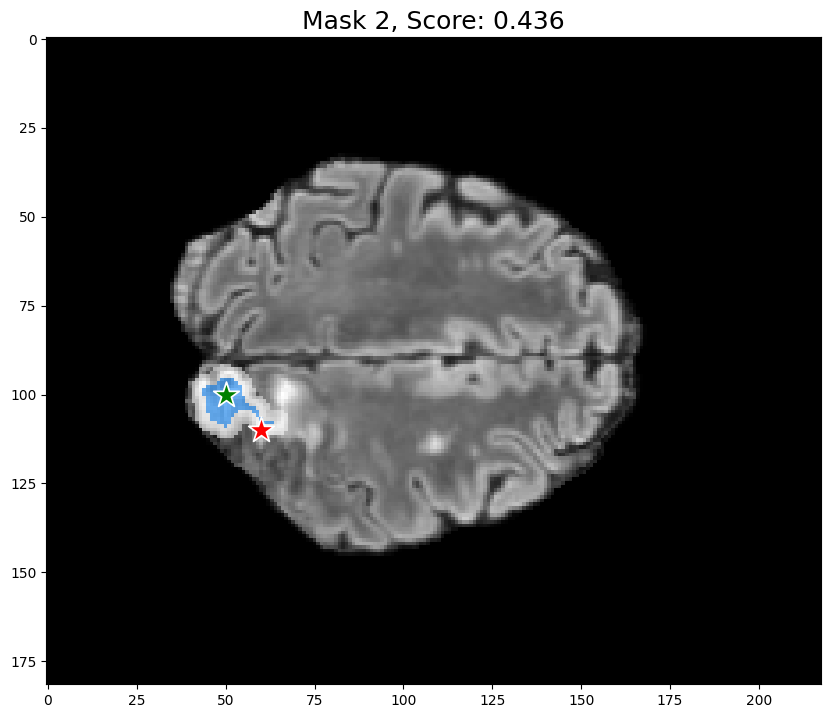

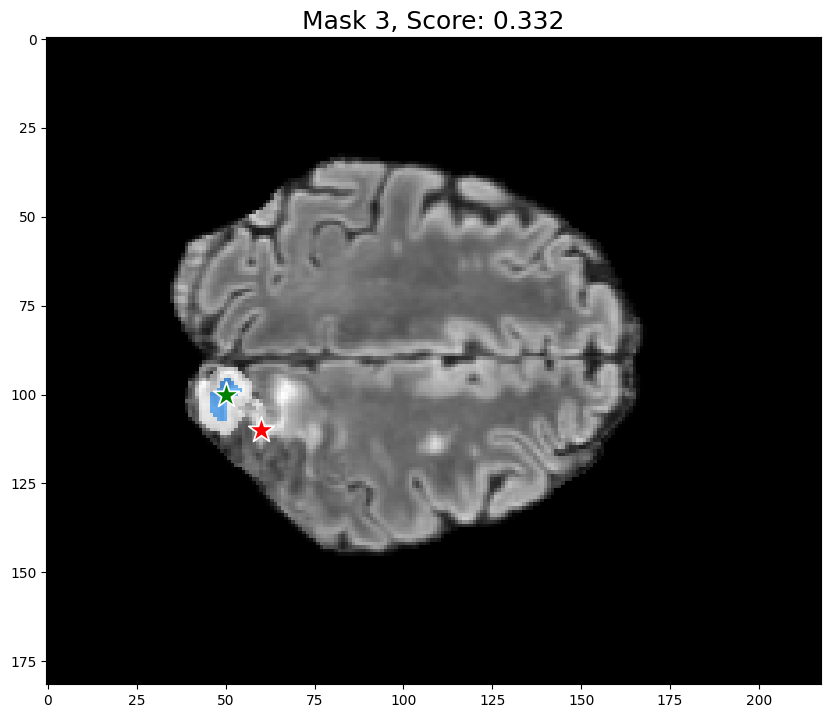

In [31]:
show_masks(image, masks, scores, point_coords=input_point, input_labels=input_label, borders=True)

# Point and Bounding box prompt


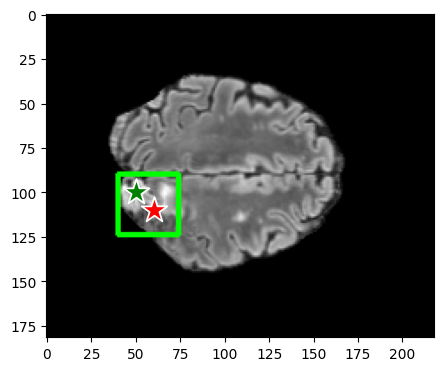

Normalized box input: [0.2637614607810974, 0.5906593203544617, 0.16055046021938324, 0.19230769574642181]

Displaying masks with both point and box prompts: (3, 182, 218)
Scores shape: (3,)    
Scores : [1.7229468e-08 1.9557774e-08 9.2550181e-09]    
Logits shape: (3, 288, 288)    
(218, 182)


In [ ]:
box_point_bbox = torch.tensor([40.0, 90.0, 35.0, 35.0]).view(-1, 4)
box_point_cxcywh = box_xywh_to_cxcywh(box_point_bbox)

point_input = np.array([[50, 100], [60, 110]])
point_label = np.array([1, 0])


img0 = Image.open(image_path)
image_with_box = draw_box_on_image(img0, box_point_bbox.flatten().tolist())

plt.figure(figsize=(5, 5))
plt.imshow(image_with_box)
show_points(point_input, point_label, plt.gca())
plt.axis('on')
plt.show()  

# point_label = np.expand_dims(point_label, axis=0)


norm_box_cxcywh = normalize_bbox(box_point_cxcywh, width, height).flatten().tolist()
print("Normalized box input:", norm_box_cxcywh)

inference_state_point_bbox = processor.set_image(image)

print(f"")

processor.reset_all_prompts(inference_state_point_bbox)
# inference_state_point_bbox = processor.add_geometric_prompt(
#     state=inference_state, box=norm_box_cxcywh, label=True
# )

# inference_state_point_bbox = processor.add_point_prompt(
#     state=inference_state_point_bbox,
#     points=point_input,
#     labels=point_label
# )
masks, scores, logits = model.predict_inst(
    inference_state_point_bbox,
    point_coords=point_input,   # shape (N, 2)
    point_labels=point_label,   # shape (N,)
    box=box_point_bbox.cpu().numpy(),         # shape (M, 4) or (1, 4)
    multimask_output=True,
)
print("Displaying masks with both point and box prompts:", masks.shape)
print(f"Scores shape: {scores.shape}    ")
print(f"Scores : {scores}    ")
print(f"Logits shape: {logits.shape}    ")
print(f"{image.size}")

# plot_results(img0, inference_state)

Sorted indices: [0 1 2]
Displaying masks with both point and box prompts: (3, 182, 218)
Scores shape: (3,)    
Logits shape: (3, 288, 288)    
[40.0, 90.0, 35.0, 35.0]


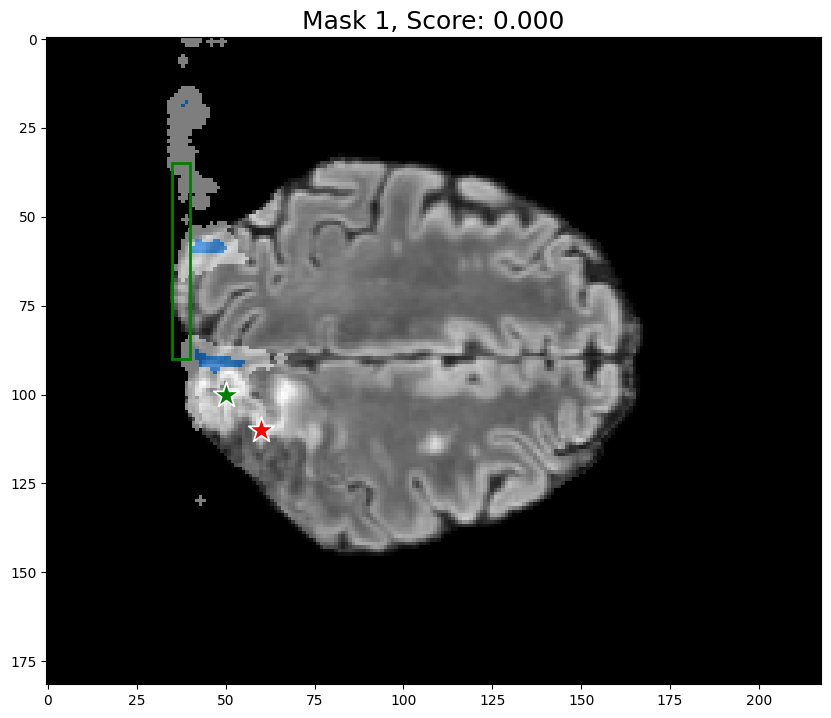

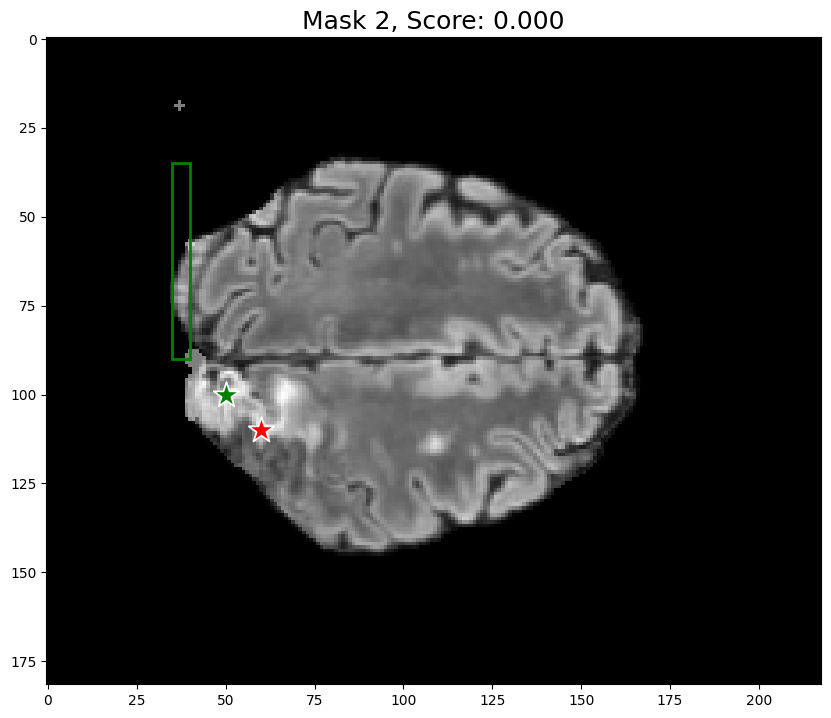

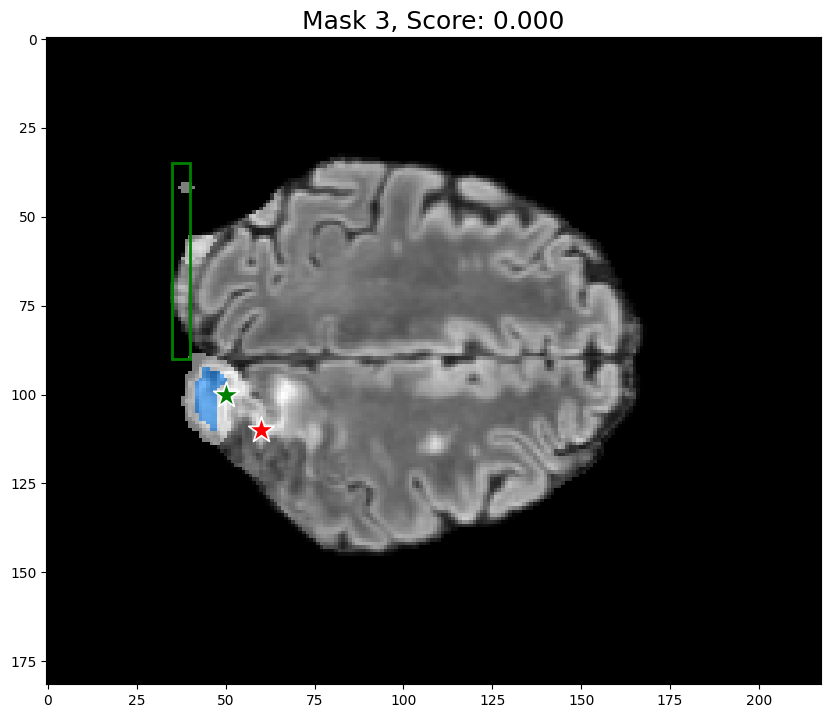

In [39]:
sorted_ind = np.argsort(scores)[::-1]
print("Sorted indices:", sorted_ind)
masks = masks[sorted_ind]
scores = scores[sorted_ind]
logits = logits[sorted_ind]

print("Displaying masks with both point and box prompts:", masks.shape)
print(f"Scores shape: {scores.shape}    ")
print(f"Logits shape: {logits.shape}    ")
print(f"{box_input_xywh_point_bbox.flatten().tolist()}")
show_masks(image, masks, scores, point_coords=point_input, input_labels=point_label, box_coords=box_input_xywh_point_bbox.flatten().tolist(), borders=True)